**PROBLEM**

Na tapet bierzemy stochastyczne równanie różniczkowe postaci:
$$
\begin{cases}
dX_t = a(t, X_t)dt + b(t, X_t)dW_t \\
X_0 = x_0
\end{cases}.
$$
**SCHEMAT EULERA-MARUYAMY**

Zaczniemy od metody Eulera-Maruyamy, która zwraca ciąg aproksymacji $\{Y_n\}_{n=0}^{N}$ w punktach $0=t_0<\dots <t_N = T,$ gdzie:
$$
\begin{cases}
Y_0 = x_0 \\
Y_{n+1} = Y_n + a(t_n, Y_n) \Delta t_n + b(t_n, Y_n) \Delta W_n
\end{cases},
$$
gdzie $\Delta t_n = t_{n+1} - t_n ,$ natomiast $\Delta W_n = W_{n+1} - W_n ,\space n = 0,\dots , N-1.$

In [11]:
import numpy as np
from matplotlib import pyplot as plt
import sympy as sp

In [2]:
def eulerMaruyama(x0, T, a, b, N):
    h = T/(N-1) # długość kroku
    t = np.linspace(0, T, N) # podział czasu
    deltat = t[1:] - t[:-1] # przyrosty czasu

    # W to biały szum
    W = np.zeros(N)
    W[1:] = np.sqrt(h)*np.random.randn(N-1) # symulowanie procesu Wienera
    W = np.cumsum(W)
    deltaW = W[1:] - W[:-1] # przyrosty szumu

    # Y to nasz ciąg aproksymacji
    Y = x0 * np.ones(N)
    for k in range(N-1):
        Y[k+1] = Y[k] + a(t[k], Y[k])*deltat[k] + b(t[k], Y[k])*deltaW[k]
    return t, Y


**POSKROMIONY SCHEMAT EULERA**

Teraz przedstawimy poskromiony schemat Eulera. Tworzymy ciąg procesów według wzoru:

$$
\begin{cases}
dX_{n+1} (t) = a_n \Big( t, X_n \big( \kappa _n (t)\big) \Big) dt + b\Big( t, X_n \big( \kappa _n (t)\big) \Big) dW(t) \\
dX_{n} (0) = X(t) 
\end{cases},
$$
gdzie
$$ \kappa _n (t) = \frac{\lfloor nt \rfloor}{n}, $$
oraz
$$
b_n (t, x) = \frac{b(t, x)}{1 + n^{-\alpha}|b(t, x)|}. 
$$
Należy pamiętać, że $\alpha$ to arbitralnie wybrany parametr, spełniający zależność $\alpha \in \big(0,\space \frac{1}{2}\big).$

In [3]:
def eulerTamed(x0, T, a, b, N, alpha):

    a_N = lambda t, X: (a(t, X))/(1 + N**(-alpha)*np.abs(a(t, X)))

    h = T/(N-1) # długość kroku
    t = np.linspace(0, T, N) # podział czasu
    deltat = t[1:] - t[:-1] # przyrosty czasu

    # W to biały szum
    W = np.zeros(N)
    W[1:] = np.sqrt(h)*np.random.randn(N-1) # symulowanie procesu Wienera
    W = np.cumsum(W)
    deltaW = W[1:] - W[:-1] # przyrosty szumu

    # Y to nasz ciąg aproksymacji
    Y = x0 * np.ones(N)
    for k in range(N-1):
        Y[k+1] = Y[k] + a_N(t[k], Y[k])*deltat[k] + b(t[k], Y[k])*deltaW[k]
    return t, Y

Określenie parametrów modelu:

In [4]:
a = lambda t, X: t**(0.5)
b = lambda t, X: X/(t+1)
N = 100
x0 = 1
T = 0.5
alpha = 0.1

Wizualizacja:

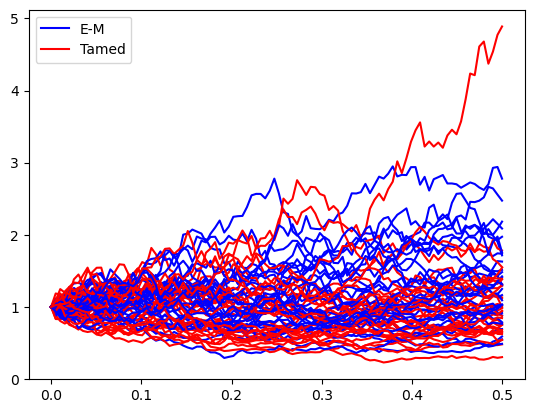

In [5]:
for i in range(30):
    plt.plot(eulerMaruyama(x0, T, a, b, N)[0], eulerMaruyama(x0, T, a, b, N)[1], color = 'b')
    plt.plot(eulerTamed(x0, T, a, b, N, 0.5)[0], eulerTamed(x0, T, a, b, N, 0.5)[1], color = 'r')
plt.plot(eulerMaruyama(x0, T, a, b, N)[0], eulerMaruyama(x0, T, a, b, N)[1], color = 'b', label = 'E-M')
plt.plot(eulerTamed(x0, T, a, b, N, alpha)[0], eulerTamed(x0, T, a, b, N, alpha)[1], color = 'r', label = 'Tamed')

plt.legend()
plt.show()

In [17]:
a = lambda t, X: X**3 # dryf
b = lambda t, X: t + X # dyfuzja
N = 30
x0 = 0
T = 1.6
alpha = 1

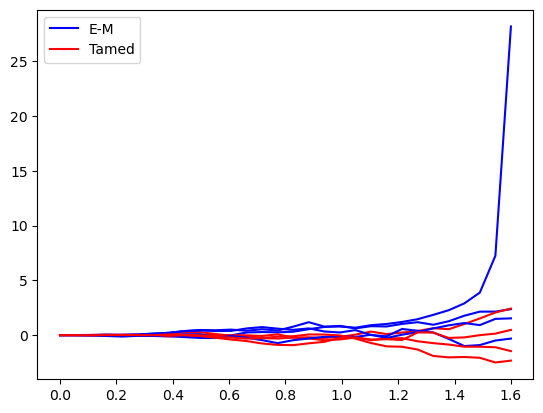

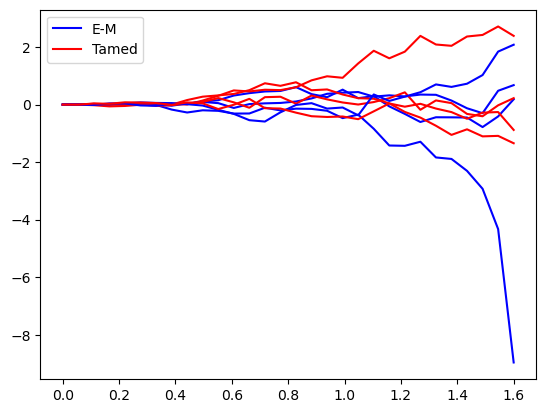

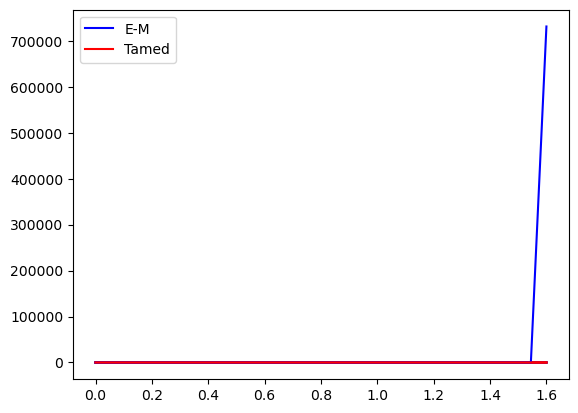

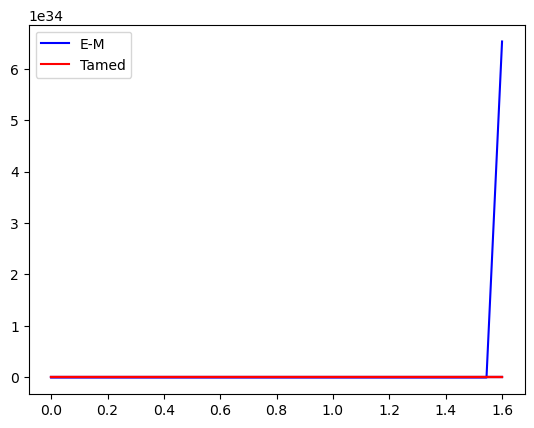

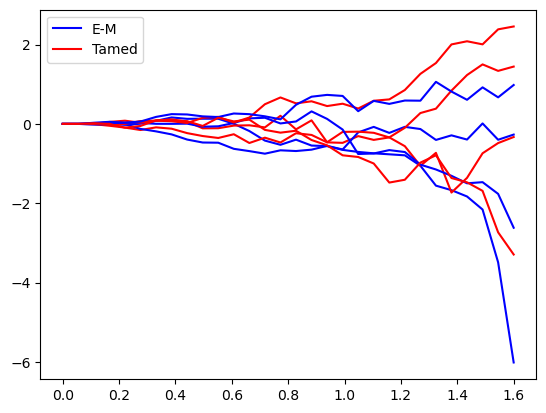

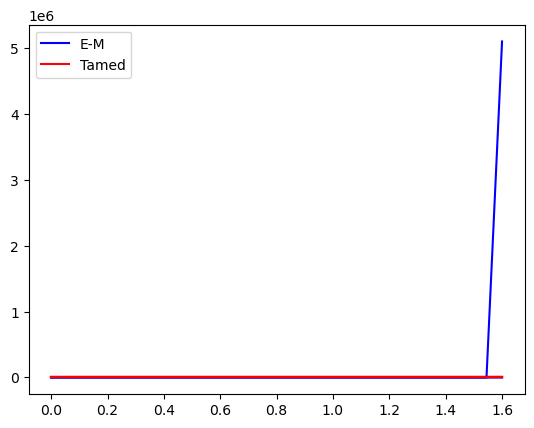

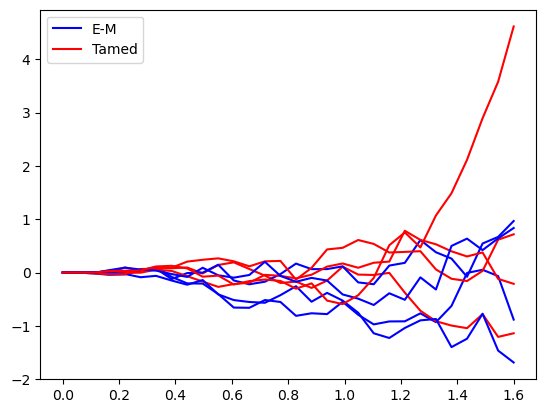

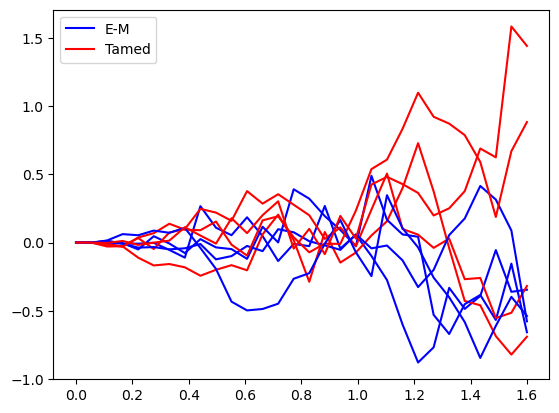

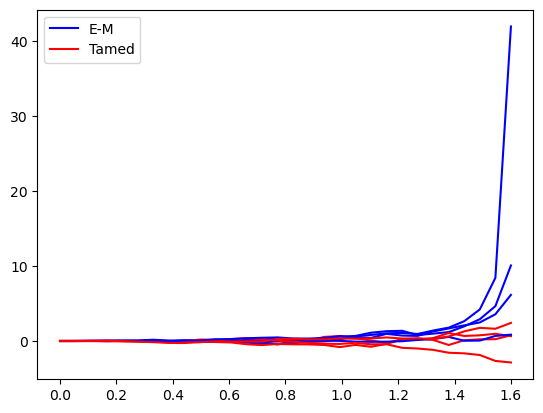

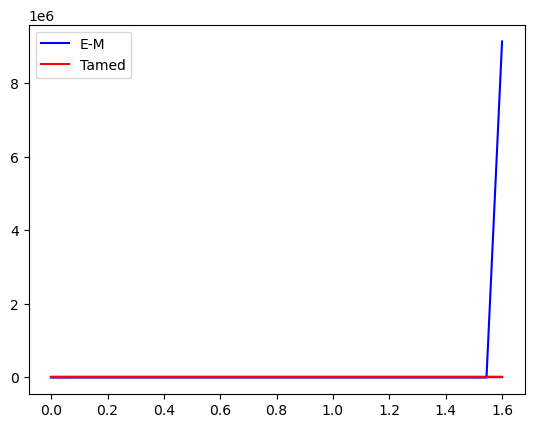

In [10]:
for k in range(10):
    for i in range(3):
        plt.plot(eulerMaruyama(x0, T, a, b, N)[0], eulerMaruyama(x0, T, a, b, N)[1], color = 'b')
        plt.plot(eulerTamed(x0, T, a, b, N, 0.5)[0], eulerTamed(x0, T, a, b, N, 0.5)[1], color = 'r')
    plt.plot(eulerMaruyama(x0, T, a, b, N)[0], eulerMaruyama(x0, T, a, b, N)[1], color = 'b', label = 'E-M')
    plt.plot(eulerTamed(x0, T, a, b, N, alpha)[0], eulerTamed(x0, T, a, b, N, alpha)[1], color = 'r', label = 'Tamed')

    plt.legend()
    plt.show()

**SCHEMAT ZAMKNIĘTY EULERA**

Schemat zamknięty Eulera dany jest formułą:
$$
\begin{cases}
Y_0 = X_0 \\
Y_{k+1} = Y_k + a(t_{k+1} ,Y_{k+1})\Delta t_k + b(t_{k+1} ,Y_{k+1})\Delta W_k \quad, k=0,\dots ,N-1.
\end{cases}
$$

Zaletą tej metody jest wysoka stabilność, lecz pojawia się problem: szukana wartość $Y_{k+1}$ jest uwikłana przez funkcje $a$ oraz $b.$ Dlatego **w każdym kroku** jesteśmy zmuszeni do rozwiązania nieliniowego równania, co zwiększa koszt aproksymacji. 

In [50]:
def eulerImplicit(x0, T, a, b, N):
    h = T/(N-1) # długość kroku
    t = np.linspace(0, T, N) # podział czasu
    deltat = t[1:] - t[:-1] # przyrosty czasu

    # W to biały szum
    W = np.zeros(N)
    W[1:] = np.sqrt(h)*np.random.randn(N-1) # symulowanie procesu Wienera
    W = np.cumsum(W)
    deltaW = W[1:] - W[:-1] # przyrosty szumu

    # Y to nasz ciąg aproksymacji
    Y = x0 * np.ones(N)
    y = sp.symbols('y')
    for k in range(N-1):
        Y[k+1] = sp.nsolve(Y[k] + a(t[k+1], y)*deltat[k] + b(t[k+1], y)*deltaW[k] - y, y, 0) 
    return t, Y

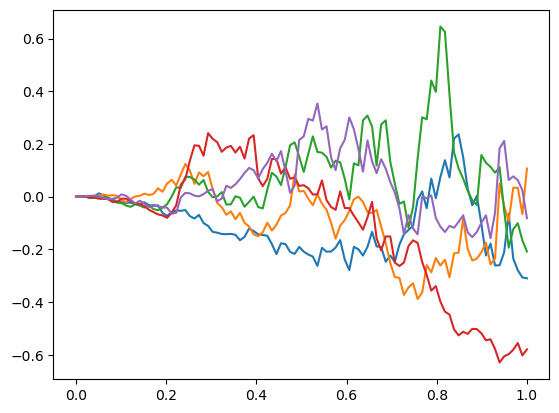

In [105]:
for k in range(5): plt.plot(eulerImplicit(x0, 1, a, b, 100)[0], eulerImplicit(x0, 1, a, b, 100)[1])
plt.show()

In [25]:
x = sp.symbols('x')
print(sp.nsolve(x**2 - 2, x, 1))

1.41421356237310
